<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/decisiontree_iris_species.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Species Classification using Decision Tree

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Load Dataset

df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/Iris%20(5).csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Drop unwanted column

df = df.drop(columns=['Id']).reset_index(drop=True)

# There are missing 'Species' data in the dataset with 'NaN' at index 150 to 157
df.tail(8)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
150,5.6,2.9,4.2,1.3,NaN
151,7.1,3.2,6.0,1.8,NaN
152,4.6,2.3,1.3,0.3,NaN
153,7.5,3.0,6.6,2.1,NaN
154,5.7,3.0,4.2,1.2,NaN
155,5.5,3.4,1.5,0.4,NaN
156,4.7,3.0,1.4,0.3,NaN
157,7.6,3.0,6.1,2.3,NaN


In [ ]:
# Calculate mean of features for each species
mean_features = df.dropna().groupby('Species').mean()
mean_features

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [ ]:
# Indices with NaN species
missing_indices = range(150, 158)

# Features
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Classify
for idx in missing_indices:
    row = df.loc[idx, features].values
    distances = mean_features.apply(lambda x: np.linalg.norm(row - x.values), axis=1)
    predicted_species = distances.idxmin()
    df.at[idx, 'Species'] = predicted_species
df.tail(8)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
150,5.6,2.9,4.2,1.3,Iris-versicolor
151,7.1,3.2,6.0,1.8,Iris-virginica
152,4.6,2.3,1.3,0.3,Iris-setosa
153,7.5,3.0,6.6,2.1,Iris-virginica
154,5.7,3.0,4.2,1.2,Iris-versicolor
155,5.5,3.4,1.5,0.4,Iris-setosa
156,4.7,3.0,1.4,0.3,Iris-setosa
157,7.6,3.0,6.1,2.3,Iris-virginica


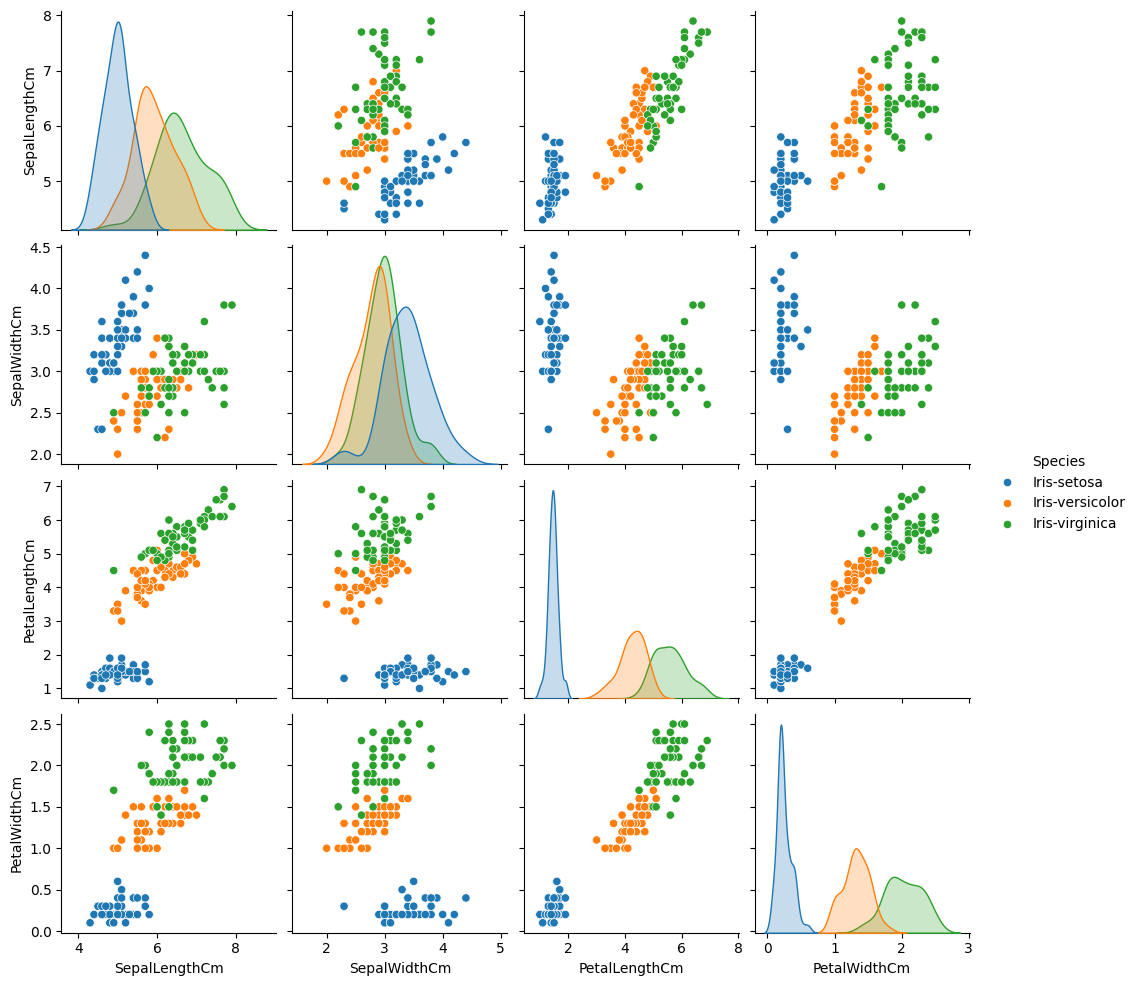

In [ ]:
sns.pairplot(df, hue = 'Species')

In [ ]:
X = df.drop(columns=['Species'])
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=50)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = dt_model.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)
report


{'Iris-setosa': {'precision': 1.0,
  'recall': 1.0,
  'f1-score': 1.0,
  'support': 17.0},
 'Iris-versicolor': {'precision': 0.8125,
  'recall': 1.0,
  'f1-score': 0.896551724137931,
  'support': 13.0},
 'Iris-virginica': {'precision': 1.0,
  'recall': 0.8333333333333334,
  'f1-score': 0.9090909090909091,
  'support': 18.0},
 'accuracy': 0.9375,
 'macro avg': {'precision': 0.9375,
  'recall': 0.9444444444444445,
  'f1-score': 0.9352142110762801,
  'support': 48.0},
 'weighted avg': {'precision': 0.94921875,
  'recall': 0.9375,
  'f1-score': 0.9378918495297807,
  'support': 48.0}}

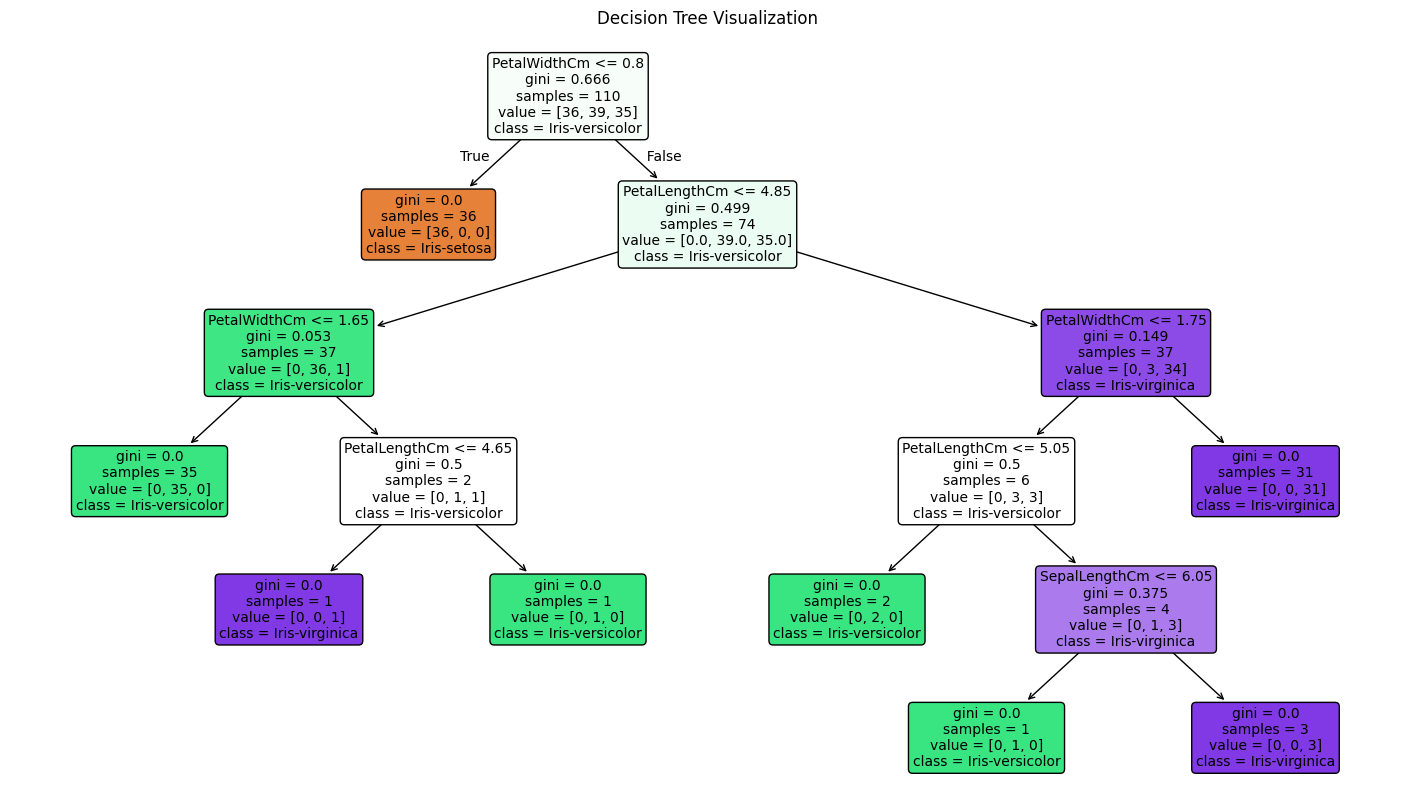

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=dt_model.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
# 1
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 2
sample1 = [[4.95, 2.9, 1.3, 0.1]]
pred1 = dt_model.predict(sample1)
print("Predicted species:", pred1[0])

# 3
sample2 = [[2.45, 3.9, 2.5, 0.2]]
pred2 = dt_model.predict(sample2)
print("Predicted species:", pred2[0])

# 4
importances = dt_model.feature_importances_
feature_names = X.columns
most_important = feature_names[importances.argmax()]
print("Most important feature:", most_important)

# 5
print("Number of terminal (leaf) nodes:", dt_model.get_n_leaves())

Accuracy: 0.9375
Predicted species: Iris-setosa
Predicted species: Iris-setosa
Most important feature: PetalWidthCm
Number of terminal (leaf) nodes: 8


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Conclusion

The Decision Tree Classifier achieved an accuracy of **0.9375** on the test set. The most important feature for classification was **PetalWidthCm**. The model successfully predicted 'Iris-setosa' for the provided sample inputs, and it has 8 terminal (leaf) nodes.